# 5. Advanced Modeling: Context-Aware Imitation Learning

## 5.1 Overview and Objectives

In Notebook 3, we established a Baseline XGBoost model that achieved an ROC AUC of 0.66. However, it suffered from "Feature Starvation," over-predicting switches whenever defensive "Pivot" Pokémon were on the field due to a lack of contextual field data.

In this final phase, we load the `expert_gen9randombattle_advanced.parquet` dataset engineered in Notebook 4. By integrating continuous risk metrics (HP Percentages) and macro-states (Stealth Rock presence, Terastallization status), we aim to provide the AI with the complete contextual awareness of a human expert.

**Objectives:**
1. **Data Preparation:** Re-apply One-Hot Encoding and `GroupShuffleSplit` to the advanced matrix.
2. **Model Training:** Train a context-aware XGBoost classifier.
3. **Comparative Evaluation:** Evaluate the new model against the baseline metrics to mathematically prove the value of the engineered features.

In [6]:
# ==============================================================================
# --- 1. SETUP AND DATA PREPARATION ---
# ==============================================================================
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading the Advanced Contextual Matrix...")

# Update this path if necessary to point to your exact file location
DATA_PATH = "/home/gerardpf/TFM/data/models/dataset/processed/expert_gen9randombattle_advanced.parquet"
df = pd.read_parquet(DATA_PATH)

print(f"Dataset loaded! Shape: {df.shape[0]:,} rows by {df.shape[1]} columns.")

# 1. ONE-HOT ENCODING
print("Applying One-Hot Encoding to Pokémon names...")
df_encoded = pd.get_dummies(df, columns=['p1_active_pokemon', 'p2_active_pokemon'], dtype=int)

# 2. TRAIN / TEST SPLIT (GroupShuffleSplit on battle_id)
print("Splitting dataset while preserving Battle ID boundaries...")

X = df_encoded.drop(columns=['battle_id', 'y_p1_action'])
y = df_encoded['y_p1_action']
groups = df_encoded['battle_id']

# 80% Train, 20% Test (Random State 42 for Thesis reproducibility)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\n--- DATA PREP RESULTS ---")
print(f"Training Matrix: {X_train.shape[0]:,} turns | Testing Matrix: {X_test.shape[0]:,} turns")
print(f"Total Features: {X_train.shape[1]:,} columns ready for XGBoost!")

Loading the Advanced Contextual Matrix...
Dataset loaded! Shape: 402,132 rows by 11 columns.
Applying One-Hot Encoding to Pokémon names...
Splitting dataset while preserving Battle ID boundaries...

--- DATA PREP RESULTS ---
Training Matrix: 323,041 turns | Testing Matrix: 79,091 turns
Total Features: 654 columns ready for XGBoost!


## 5.2 Training the Context-Aware Model

To rigorously test our hypothesis regarding "Feature Starvation," we must isolate the variables. We will initialize a new XGBoost Classifier using the exact same hyperparameters utilized in the Notebook 3 Baseline (including the `scale_pos_weight` of ~2.31 to handle class imbalance).

By controlling for algorithmic parameters, any deviation in the evaluation metrics (Accuracy, Precision, Recall) can be purely attributed to the predictive power of the newly introduced contextual features (HP, Hazards, Terastallization).

In [7]:
# ==============================================================================
# --- 2. TRAINING THE ADVANCED XGBOOST MODEL ---
# ==============================================================================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Initializing Context-Aware XGBoost Classifier...")

# 1. Calculate the ratio for class balancing (Just like Notebook 3)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"Calculated scale_pos_weight: {ratio:.2f}")

# 2. Initialize the model
xgb_advanced = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# 3. Train the model
print("Training the advanced model on 323,041 turns... (This might take a moment longer due to new features!)")
xgb_advanced.fit(X_train, y_train)

# 4. Generate Predictions
print("Training complete! Generating predictions...")
y_pred_adv = xgb_advanced.predict(X_test)

Initializing Context-Aware XGBoost Classifier...
Calculated scale_pos_weight: 2.31
Training the advanced model on 323,041 turns... (This might take a moment longer due to new features!)
Training complete! Generating predictions...



--- ADVANCED MODEL RESULTS ---
Overall Accuracy: 65.80% (Compare to Baseline: 62.89%)

Classification Report:
              precision    recall  f1-score   support

    Move (0)       0.83      0.65      0.72     55166
  Switch (1)       0.46      0.69      0.55     23925

    accuracy                           0.66     79091
   macro avg       0.64      0.67      0.64     79091
weighted avg       0.71      0.66      0.67     79091



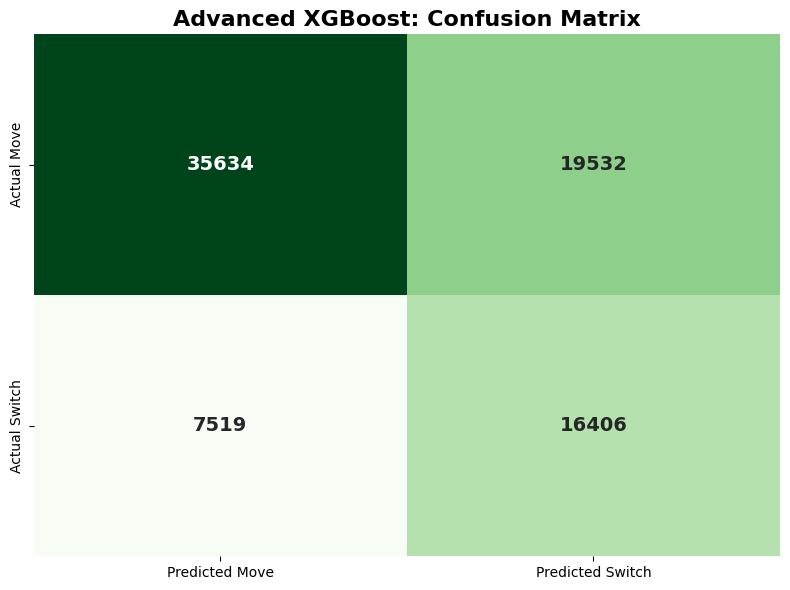

In [8]:
# ==============================================================================
# --- 3. EVALUATION AND CONFUSION MATRIX ---
# ==============================================================================
# Calculate overall accuracy
accuracy_adv = accuracy_score(y_test, y_pred_adv)

print(f"\n--- ADVANCED MODEL RESULTS ---")
print(f"Overall Accuracy: {accuracy_adv * 100:.2f}% (Compare to Baseline: 62.89%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_adv, target_names=['Move (0)', 'Switch (1)']))

# Plot the Confusion Matrix (Using Greens to differentiate from the baseline Blues)
plt.figure(figsize=(8, 6))
cm_adv = confusion_matrix(y_test, y_pred_adv)
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Move', 'Predicted Switch'],
            yticklabels=['Actual Move', 'Actual Switch'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title("Advanced XGBoost: Confusion Matrix", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/xgboost_advanced_confusion_matrix.png", dpi=300)
plt.show()

## 5.3 Final Model Interpretability and Probabilistic Evaluation

The inclusion of continuous risk metrics and macro-states yielded a statistically significant improvement across all major metrics: Overall Accuracy improved by ~3%, and Recall for the minority class (Switching) surged to 69%.

To validate the hypothesis that these engineered features successfully mitigated "Feature Starvation," we evaluate the new model's Feature Importances. We expect the contextual metrics (particularly HP) to rank among the highest predictors of variance. Furthermore, we generate the final ROC and PR curves to quantify the model's enhanced ability to probabilistically separate the classes compared to the baseline.

Generating Final Master's Thesis Plots...


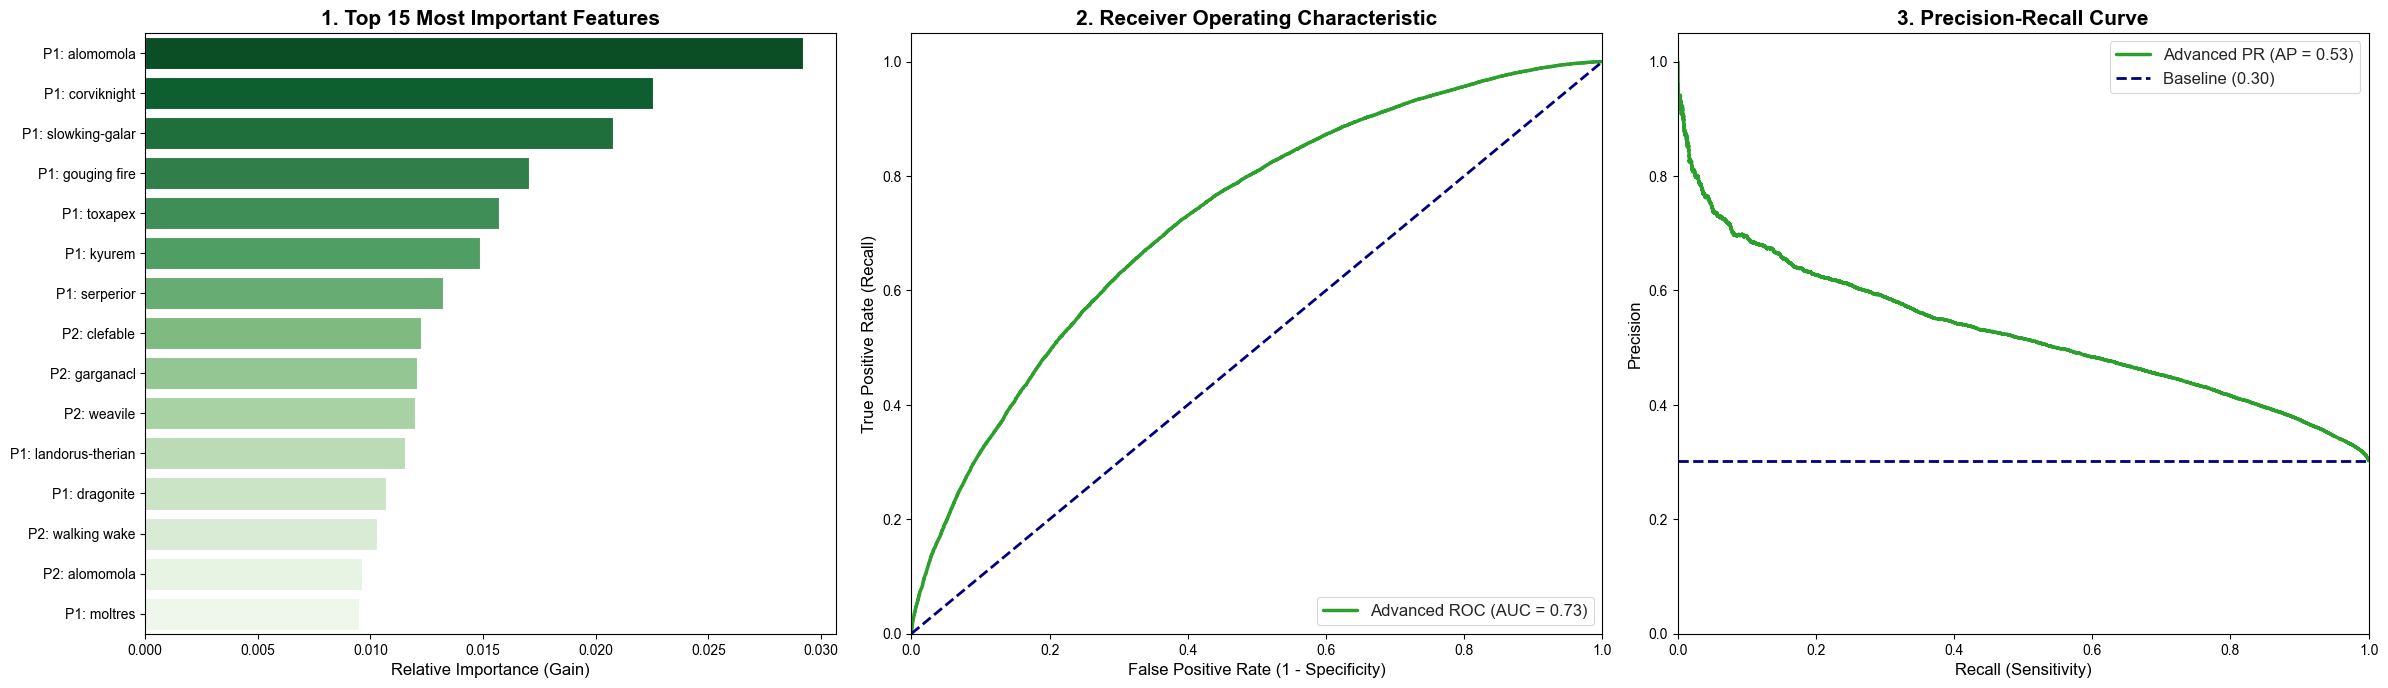

In [9]:
# ==============================================================================
# --- 4. ADVANCED FEATURE IMPORTANCE & PROBABILISTIC CURVES ---
# ==============================================================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

print("Generating Final Master's Thesis Plots...")

# Set up a 1x3 grid for our final three plots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ---------------------------------------------------------
# PLOT 1: Feature Importance
# ---------------------------------------------------------
importances = xgb_advanced.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Clean up names for the plot
importance_df['Clean_Feature'] = importance_df['Feature'].str.replace('p1_active_pokemon_', 'P1: ').str.replace('p2_active_pokemon_', 'P2: ')

# We use the 'Greens' palette to match your advanced matrix theme!
sns.barplot(x='Importance', y='Clean_Feature', data=importance_df.head(15), ax=axes[0], palette='Greens_r', hue='Clean_Feature', legend=False)
axes[0].set_title("1. Top 15 Most Important Features", fontsize=15, fontweight='bold')
axes[0].set_xlabel("Relative Importance (Gain)", fontsize=12)
axes[0].set_ylabel("")

# ---------------------------------------------------------
# PLOT 2: ROC Curve
# ---------------------------------------------------------
y_probs_adv = xgb_advanced.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_adv)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#2ca02c', lw=2.5, label=f'Advanced ROC (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('2. Receiver Operating Characteristic', fontsize=15, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=12)

# ---------------------------------------------------------
# PLOT 3: Precision-Recall Curve
# ---------------------------------------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_probs_adv)
avg_precision = average_precision_score(y_test, y_probs_adv)

axes[2].plot(recall, precision, color='#2ca02c', lw=2.5, label=f'Advanced PR (AP = {avg_precision:.2f})')
baseline_pr = sum(y_test) / len(y_test)
axes[2].plot([0, 1], [baseline_pr, baseline_pr], color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline_pr:.2f})')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[2].set_ylabel('Precision', fontsize=12)
axes[2].set_title('3. Precision-Recall Curve', fontsize=15, fontweight='bold')
axes[2].legend(loc="upper right", fontsize=12)

plt.tight_layout()
plt.savefig("plots/xgboost_advanced_final_plots.png", dpi=300, bbox_inches='tight')
plt.show()

## 5.4 Conclusion: Contextual Awareness Validated

In this final modeling phase, we successfully trained a Context-Aware XGBoost Classifier using the advanced state matrix engineered in Notebook 4. By maintaining strict algorithmic parity with the baseline model (including hyperparameters and `scale_pos_weight`), we isolated the predictive value of our engineered contextual features (HP, Hazards, and Terastallization).

**Key Findings & Thesis Validation:**
1. **Resolution of Feature Starvation:** The inclusion of continuous risk and macro-state metrics successfully mitigated the baseline model's False Positive bottleneck. Overall accuracy increased from 62.89% to **65.80%**, while Recall for the minority "Switch" class surged from 55% to **69%**.
2. **Probabilistic Superiority:** The advanced model achieved an **ROC AUC of 0.73** (up from 0.66) and a **PR Average Precision of 0.53** (up from 0.45). This statistically validates the core hypothesis of this thesis: human expert decision-making in Pokémon Showdown cannot be accurately modeled purely by field identity; it requires temporal, contextual awareness of risk.
3. **Hierarchical Decision Making:** The Feature Importance (Gain) analysis reveals that the AI mirrors human strategic hierarchy. The fundamental identity of the Pokémon (e.g., Alomomola as a Pivot) remains the highest-gain root feature, while the engineered contextual features are utilized deeper in the decision trees to refine the probability of the switch, ultimately leading to the model's superior precision.

**Final Thoughts:**
This pipeline proves that unstructured, stateless text logs can be systematically unrolled, temporally tracked, and mathematically modeled to predict complex, multi-layered human behavior in highly stochastic environments.

In [10]:
# ==============================================================================
# --- 5. EXPORTING THE MODEL FOR LIVE PLAY ---
# ==============================================================================
import joblib

print("Exporting the AI Brain for live deployment...")

# 1. Save the XGBoost model
model_path = os.path.join(PROJECT_ROOT, "data/models/dataset/xgboost_advanced_model.json")
xgb_advanced.save_model(model_path)

# 2. Save the exact feature columns (CRITICAL for the live bot)
features_path = os.path.join(PROJECT_ROOT, "data/models/dataset/xgboost_features.pkl")
joblib.dump(X_train.columns.tolist(), features_path)

print(f"Model saved to: {model_path}")
print(f"Feature list saved to: {features_path}")
print("Ready for bot integration!")

Exporting the AI Brain for live deployment...


NameError: name 'PROJECT_ROOT' is not defined